  LOADING DATASET
Loaded shape     : (52020, 8)
Columns          : ['review_id', 'product_name', 'user_review', 'rating', 'verified_purchase', 'review_date', 'price', 'helpful_votes']

Null values BEFORE cleaning:
review_id               0
product_name         2091
user_review          3120
rating                  0
verified_purchase    2608
review_date          2530
price                3735
helpful_votes        4113
dtype: int64

Duplicate rows   : 0

Rating distribution (raw):
rating
1     8827
2     8867
3    13270
4    10529
5    10527
Name: count, dtype: int64

  PHASE 1 : DATA CLEANING + NLP PREPROCESSING

Step 1a | Remove duplicates    : 52020 → 52020 rows removed 0
Step 1b | Drop null reviews    : 52020 → 48900 rows removed 3120
Step 1c | Fill remaining nulls : Done — 0 nulls remaining

Sentiment distribution after cleaning:
sentiment
Positive    19782
Negative    16607
Neutral     12511
Name: count, dtype: int64

Step 2  | Text Cleaning...
         Removing: HTML tags, punctu

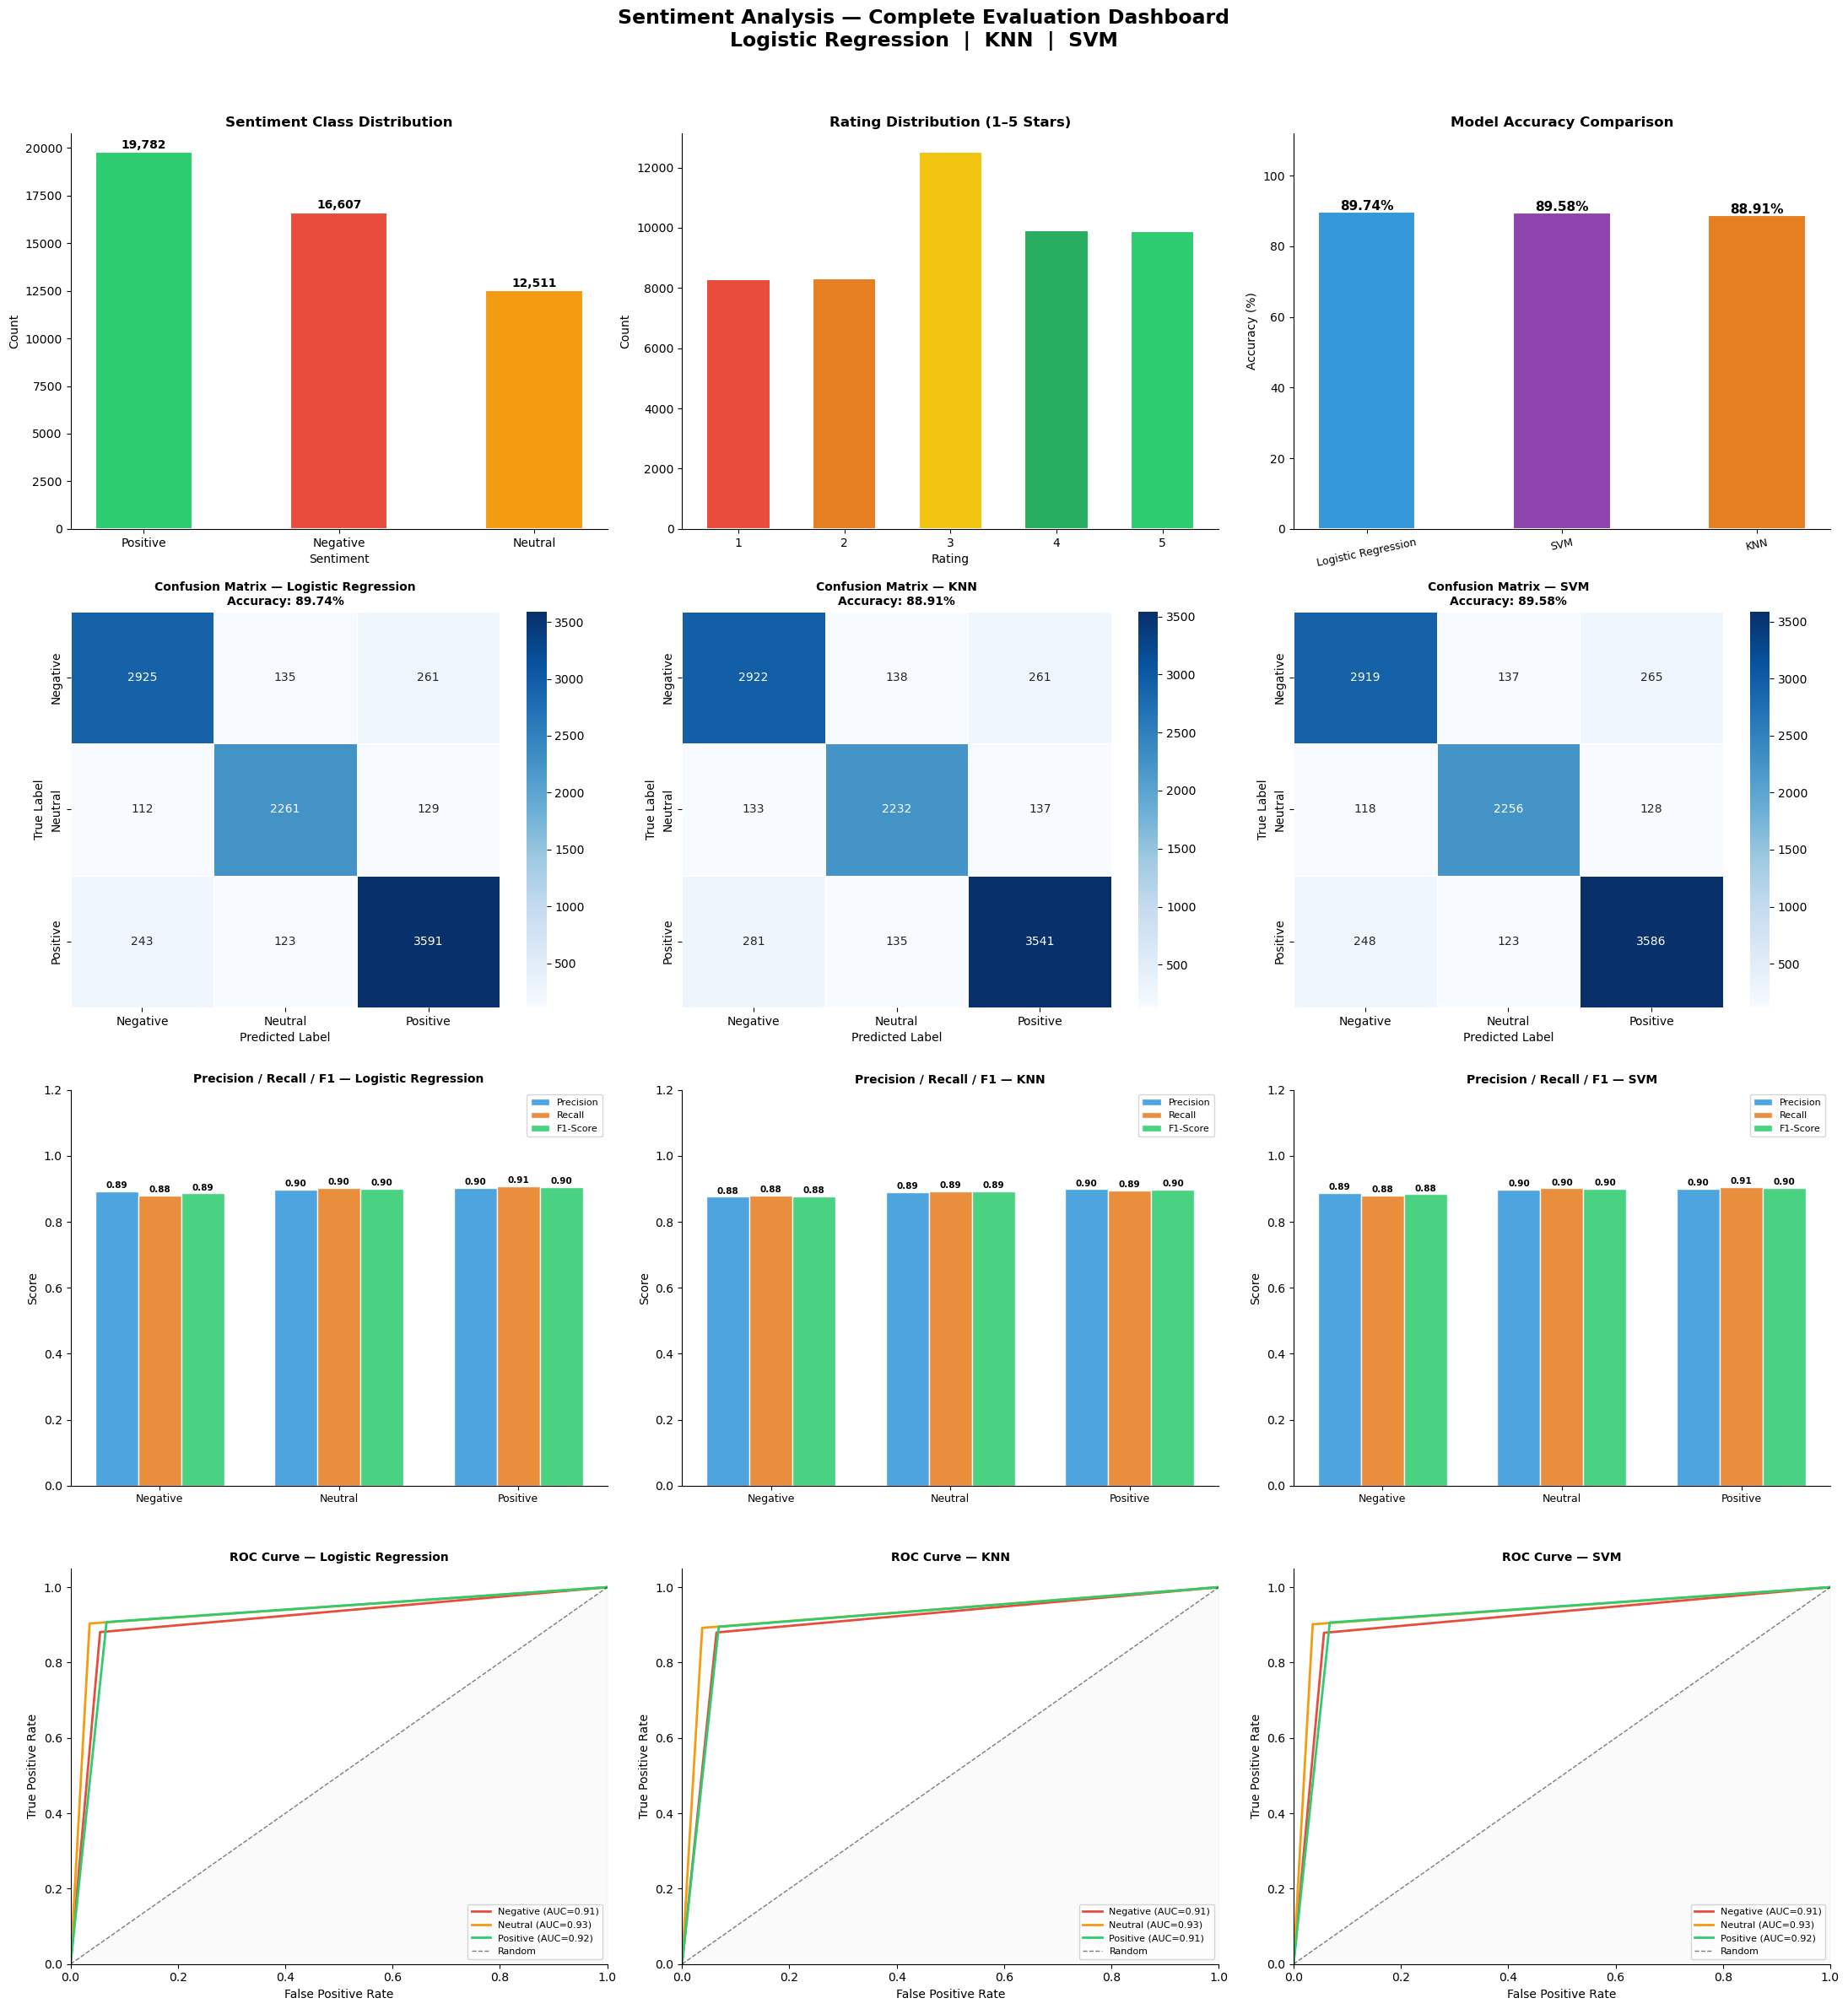

All 12 graphs saved → sentiment_evaluation.png

  FINAL MODEL ACCURACY SUMMARY
  Logistic Regression        89.74%
  SVM                        89.58%
  KNN                        88.91%

  Best Model  : Logistic Regression
  Accuracy    : 89.74%
  Precision   : 89.74%
  Recall      : 89.74%
  F1-Score    : 89.74%

  SAVING PREDICTED SENTIMENTS TO DATASET

  Model used             : Logistic Regression
  Total rows predicted   : 48900
  Correct predictions    : 43984
  Wrong predictions      : 4916

  Predicted sentiment counts:
predicted_sentiment
Positive    20106
Negative    16304
Neutral     12490

  Output saved to        : product_reviews_with_predictions.csv

  Sample rows (first 5):
  Review    : Bad  Power Bank at a high price. Quality is weak and performance 
  Actual    : Negative      Predicted: Negative      Correct: True

  Review    : REAlLy ImprEsseD witH tHis LAptoP StAND. EXcELleNt QuALity AND Br
  Actual    : Positive      Predicted: Positive      Correct: True

  Re

In [2]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

warnings.filterwarnings("ignore")

CLASSES      = ["Negative", "Neutral", "Positive"]
MODEL_COLORS = {"Logistic Regression": "#3498db", "KNN": "#e67e22", "SVM": "#8e44ad"}
SENT_COLORS  = {"Positive": "#2ecc71", "Neutral": "#f39c12", "Negative": "#e74c3c"}


# ================================================================
#   LOAD DATASET
# ================================================================
print("=" * 65)
print("  LOADING DATASET")
print("=" * 65)

df = pd.read_csv("product_reviews_messy.csv")
print(f"Loaded shape     : {df.shape}")
print(f"Columns          : {df.columns.tolist()}")
print(f"\nNull values BEFORE cleaning:")
print(df.isnull().sum())
print(f"\nDuplicate rows   : {df.duplicated().sum()}")
print(f"\nRating distribution (raw):")
print(df["rating"].value_counts().sort_index())


# ================================================================
#   PHASE 1 — DATA CLEANING + NLP PREPROCESSING
# ================================================================
print("\n" + "=" * 65)
print("  PHASE 1 : DATA CLEANING + NLP PREPROCESSING")
print("=" * 65)

# ── Step 1a: Remove duplicate rows ───────────────────────────────
before = len(df)
df = df.drop_duplicates()
print(f"\nStep 1a | Remove duplicates    : {before} → {len(df)} rows removed {before-len(df)}")

# ── Step 1b: Drop rows with null user_review ─────────────────────
before = len(df)
df = df.dropna(subset=["user_review"])
print(f"Step 1b | Drop null reviews    : {before} → {len(df)} rows removed {before-len(df)}")

# ── Step 1c: Fill remaining null columns ─────────────────────────
df["product_name"]      = df["product_name"].fillna("Unknown Product")
df["verified_purchase"] = df["verified_purchase"].fillna("Unknown")
df["review_date"]       = df["review_date"].fillna("Unknown")
df["price"]             = df["price"].fillna(df["price"].median())
df["helpful_votes"]     = df["helpful_votes"].fillna(0)
print(f"Step 1c | Fill remaining nulls : Done — {df.isnull().sum().sum()} nulls remaining")

# ── Step 1d: Map rating → sentiment label ────────────────────────
def map_sentiment(rating):
    if rating <= 2:   return "Negative"
    elif rating == 3: return "Neutral"
    else:             return "Positive"

df["sentiment"] = df["rating"].apply(map_sentiment)
print(f"\nSentiment distribution after cleaning:")
print(df["sentiment"].value_counts())

# ── Step 2: Text Cleaning ────────────────────────────────────────
print("\nStep 2  | Text Cleaning...")
print("         Removing: HTML tags, punctuation, numbers, extra spaces")
print("         Converting: to lowercase")

def clean_text(text):
    text = str(text)
    text = re.sub(r'<[^>]+>',  ' ', text)   # Remove HTML tags
    text = re.sub(r'&[a-z]+;', ' ', text)   # Remove HTML entities
    text = re.sub(r'[^\w\s]',  ' ', text)   # Remove punctuation & special chars
    text = text.lower()                      # Convert to lowercase
    text = re.sub(r'\d+',      ' ', text)   # Remove numbers
    text = re.sub(r'\s+',      ' ', text).strip()  # Remove extra whitespace
    return text

df["cleaned_review"] = df["user_review"].apply(clean_text)

# ── Step 3: NLP Processing ───────────────────────────────────────
print("Step 3  | NLP Processing...")
print("         Tokenization → Stopword Removal → Lemmatization")

STOP_WORDS = set(ENGLISH_STOP_WORDS)

LEMMA_RULES = [
    (r'ying$','y'),(r'ies$','y'),(r'ied$','y'),
    (r'ves$','f'),(r'sses$','ss'),(r'ness$',''),
    (r'ment$',''),(r'tion$',''),(r'ings$',''),
    (r'ing$',''),(r'ers$',''),(r'er$',''),
    (r'ly$',''),(r'es$',''),(r'ed$',' '),(r's$','')
]

def lemmatize(word):
    for pat, rep in LEMMA_RULES:
        result = re.sub(pat, rep, word)
        if len(result.strip()) >= 3 and result != word:
            return result.strip()
    return word

def nlp_process(text):
    tokens = text.split()                                                     # Tokenization
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]      # Stopword removal
    tokens = [lemmatize(t) for t in tokens]                                  # Lemmatization
    tokens = [t for t in tokens if len(t) > 2]
    return " ".join(tokens)

df["processed_review"] = df["cleaned_review"].apply(nlp_process)

print("\nSample — Before & After Cleaning:")
print("-" * 65)
for i in [0, 3, 7]:
    print(f"ORIGINAL  : {str(df['user_review'].iloc[i])[:80]}")
    print(f"CLEANED   : {df['cleaned_review'].iloc[i][:80]}")
    print(f"PROCESSED : {df['processed_review'].iloc[i][:80]}")
    print()

# ── Step 4: TF-IDF Vectorization ─────────────────────────────────
print("Step 4  | TF-IDF Vectorization (Feature Extraction)...")
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),    # unigrams + bigrams
    min_df=2,              # ignore very rare terms
    sublinear_tf=True      # log(1+tf) — reduces dominance of frequent terms
)
X = tfidf.fit_transform(df["processed_review"])
y = df["sentiment"]

print(f"         TF-IDF matrix shape  : {X.shape}")
print(f"         Vocabulary sample    : {list(tfidf.vocabulary_.keys())[:8]}")

# ── Train / Test Split ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain set  : {X_train.shape[0]} samples")
print(f"Test set   : {X_test.shape[0]} samples")


# ================================================================
#   PHASE 2 — MODEL BUILDING & TRAINING
# ================================================================
print("\n" + "=" * 65)
print("  PHASE 2 : MODEL BUILDING & TRAINING")
print("=" * 65)

models = {
    "Logistic Regression": LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, solver="lbfgs"
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5, metric="cosine", algorithm="brute"
    ),
    "SVM": LinearSVC(
        C=1.0, max_iter=3000, random_state=42
    )
}

predictions = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    acc = accuracy_score(y_test, predictions[name])
    print(f"  → Test Accuracy : {acc * 100:.2f}%")


# ================================================================
#   PHASE 3 — EVALUATION & RESULTS
# ================================================================
print("\n" + "=" * 65)
print("  PHASE 3 : EVALUATION & RESULTS")
print("=" * 65)

results = []
for name, y_pred in predictions.items():
    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall":    recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)

print("\nModel Comparison Table:")
print("-" * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1-Score':>9}")
print("-" * 65)
for _, r in results_df.iterrows():
    print(f"{r['Model']:<25} {r['Accuracy']*100:>9.2f}% "
          f"{r['Precision']*100:>9.2f}% {r['Recall']*100:>7.2f}% {r['F1-Score']*100:>8.2f}%")
print("-" * 65)

for name, y_pred in predictions.items():
    print(f"\nDetailed Classification Report — {name}")
    print(classification_report(y_test, y_pred, target_names=CLASSES, zero_division=0))


# ================================================================
#   PLOTS — Complete 4-Row Evaluation Dashboard (12 graphs)
# ================================================================
print("Generating evaluation graphs...")

fig = plt.figure(figsize=(22, 24))
fig.suptitle(
    "Sentiment Analysis — Complete Evaluation Dashboard\n"
    "Logistic Regression  |  KNN  |  SVM",
    fontsize=17, fontweight="bold", y=0.99
)
plt.rcParams.update({"font.family": "DejaVu Sans"})

# ── ROW 1: Data Overview (3 charts) ──────────────────────────────

# Graph 1: Sentiment Distribution
ax1 = fig.add_subplot(4, 3, 1)
sc   = df["sentiment"].value_counts()
bars = ax1.bar(sc.index, sc.values,
               color=[SENT_COLORS[s] for s in sc.index],
               edgecolor="white", linewidth=1.5, width=0.5)
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+200,
             f'{int(b.get_height()):,}', ha='center', fontweight='bold', fontsize=10)
ax1.set_title("Sentiment Class Distribution", fontweight="bold", fontsize=12)
ax1.set_xlabel("Sentiment"); ax1.set_ylabel("Count")
ax1.spines[["top","right"]].set_visible(False)

# Graph 2: Rating Distribution
ax2 = fig.add_subplot(4, 3, 2)
rc  = df["rating"].value_counts().sort_index()
ax2.bar(rc.index, rc.values,
        color=["#e74c3c","#e67e22","#f1c40f","#27ae60","#2ecc71"],
        edgecolor="white", linewidth=1.5, width=0.6)
ax2.set_title("Rating Distribution (1–5 Stars)", fontweight="bold", fontsize=12)
ax2.set_xlabel("Rating"); ax2.set_ylabel("Count"); ax2.set_xticks([1,2,3,4,5])
ax2.spines[["top","right"]].set_visible(False)

# Graph 3: Model Accuracy Comparison
ax3 = fig.add_subplot(4, 3, 3)
mnames = results_df["Model"].tolist()
maccs  = (results_df["Accuracy"]*100).tolist()
bars3  = ax3.bar(mnames, maccs,
                 color=[MODEL_COLORS[m] for m in mnames],
                 edgecolor="white", linewidth=1.5, width=0.5)
for b, acc in zip(bars3, maccs):
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+0.4,
             f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=11)
ax3.set_title("Model Accuracy Comparison", fontweight="bold", fontsize=12)
ax3.set_ylabel("Accuracy (%)"); ax3.set_ylim(0, 112)
plt.setp(ax3.get_xticklabels(), rotation=12, fontsize=9)
ax3.spines[["top","right"]].set_visible(False)

# ── ROW 2: Confusion Matrices (3 charts) ─────────────────────────
for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = fig.add_subplot(4, 3, 4+idx)
    cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=ax, linewidths=0.5, annot_kws={"size": 10})
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f"Confusion Matrix — {name}\nAccuracy: {acc*100:.2f}%",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")

# ── ROW 3: Precision / Recall / F1 per class (3 charts) ──────────
for idx, (name, y_pred) in enumerate(predictions.items()):
    ax   = fig.add_subplot(4, 3, 7+idx)
    rep  = classification_report(y_test, y_pred, target_names=CLASSES,
                                 output_dict=True, zero_division=0)
    prec = [rep[c]["precision"] for c in CLASSES]
    rec  = [rep[c]["recall"]    for c in CLASSES]
    f1s  = [rep[c]["f1-score"]  for c in CLASSES]
    x    = np.arange(len(CLASSES)); w = 0.24
    b1 = ax.bar(x-w,  prec, w, label="Precision", color="#3498db", alpha=0.88, edgecolor="white")
    b2 = ax.bar(x,    rec,  w, label="Recall",    color="#e67e22", alpha=0.88, edgecolor="white")
    b3 = ax.bar(x+w,  f1s,  w, label="F1-Score",  color="#2ecc71", alpha=0.88, edgecolor="white")
    for xi,(p,r,f) in enumerate(zip(prec,rec,f1s)):
        ax.text(xi-w, p+0.01, f'{p:.2f}', ha='center', fontsize=7.5, fontweight='bold')
        ax.text(xi,   r+0.01, f'{r:.2f}', ha='center', fontsize=7.5, fontweight='bold')
        ax.text(xi+w, f+0.01, f'{f:.2f}', ha='center', fontsize=7.5, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(CLASSES, fontsize=9)
    ax.set_title(f"Precision / Recall / F1 — {name}", fontweight="bold", fontsize=10)
    ax.set_ylabel("Score"); ax.set_ylim(0, 1.2); ax.legend(fontsize=8)
    ax.spines[["top","right"]].set_visible(False)

# ── ROW 4: ROC Curves (3 charts) ─────────────────────────────────
y_bin     = label_binarize(y_test, classes=CLASSES)
roc_col   = {"Negative":"#e74c3c","Neutral":"#f39c12","Positive":"#2ecc71"}

for idx, (name, _) in enumerate(predictions.items()):
    ax         = fig.add_subplot(4, 3, 10+idx)
    y_pred_bin = label_binarize(predictions[name], classes=CLASSES)
    for i, cls in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:,i], y_pred_bin[:,i])
        try:    auc = roc_auc_score(y_bin[:,i], y_pred_bin[:,i])
        except: auc = 0.0
        ax.plot(fpr, tpr, label=f"{cls} (AUC={auc:.2f})", color=roc_col[cls], lw=2)
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label="Random")
    ax.fill_between([0,1],[0,1],alpha=0.04,color='gray')
    ax.set_title(f"ROC Curve — {name}", fontweight="bold", fontsize=10)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8, loc="lower right")
    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout(rect=[0,0,1,0.97])
graph_path = "sentiment_evaluation.png"
plt.savefig(graph_path, dpi=150, bbox_inches="tight")
plt.show()   # Opens all graphs on screen while running
print(f"All 12 graphs saved → {graph_path}\n")


# ================================================================
#   FINAL MODEL ACCURACY SUMMARY
# ================================================================
print("=" * 65)
print("  FINAL MODEL ACCURACY SUMMARY")
print("=" * 65)
for _, r in results_df.iterrows():
    print(f"  {r['Model']:25s}  {r['Accuracy']*100:.2f}%")

best = results_df.iloc[0]
print("=" * 65)
print(f"\n  Best Model  : {best['Model']}")
print(f"  Accuracy    : {best['Accuracy']*100:.2f}%")
print(f"  Precision   : {best['Precision']*100:.2f}%")
print(f"  Recall      : {best['Recall']*100:.2f}%")
print(f"  F1-Score    : {best['F1-Score']*100:.2f}%")
print("=" * 65)


# ================================================================
#   SAVE PREDICTED SENTIMENT BACK TO DATASET
# ================================================================
print("\n" + "=" * 65)
print("  SAVING PREDICTED SENTIMENTS TO DATASET")
print("=" * 65)

best_model_name = results_df.iloc[0]["Model"]
best_model      = models[best_model_name]

# Predict on entire cleaned dataset
all_preds = best_model.predict(X)

df["predicted_sentiment"] = all_preds
df["actual_sentiment"]    = y.values
df["prediction_correct"]  = (df["predicted_sentiment"] == df["actual_sentiment"])

output_csv = "product_reviews_with_predictions.csv"
df.to_csv(output_csv, index=False)

print(f"\n  Model used             : {best_model_name}")
print(f"  Total rows predicted   : {len(df)}")
print(f"  Correct predictions    : {df['prediction_correct'].sum()}")
print(f"  Wrong predictions      : {(~df['prediction_correct']).sum()}")
print(f"\n  Predicted sentiment counts:")
print(df["predicted_sentiment"].value_counts().to_string())
print(f"\n  Output saved to        : {output_csv}")
print("\n  Sample rows (first 5):")
sample = df[["user_review","actual_sentiment","predicted_sentiment","prediction_correct"]].head()
for _, row in sample.iterrows():
    print(f"  Review    : {str(row['user_review'])[:65]}")
    print(f"  Actual    : {row['actual_sentiment']:12s}  Predicted: {row['predicted_sentiment']:12s}  Correct: {row['prediction_correct']}")
    print()
